In [1]:
import numpy as np
import heapq
import pandas as pd

In [2]:
# -----------------------------
# PARAMETERS
# -----------------------------

SIM_TIME = 45 * 24          
DRIVER_RATE = 3
RIDER_RATE = 30
PATIENCE_RATE = 5

SPEED = 20
AREA_SIZE = 20

BASE_FARE = 3
FARE_PER_MILE = 2
PETROL_COST_PER_MILE = 0.20


In [3]:


# -----------------------------
# DRIVER CLASS
# -----------------------------

class Driver:
    def __init__(self, driver_id, location, online_until):
        self.id = driver_id
        self.location = location
        self.online_until = online_until
        self.earnings = 0
        self.status = "idle"
        self.busy_time = 0



In [4]:

# -----------------------------
# RIDER CLASS
# -----------------------------

class Rider:
    def __init__(self, rider_id, origin, destination, arrival_time, abandon_time):
        self.id = rider_id
        self.origin = origin
        self.destination = destination
        self.arrival_time = arrival_time
        self.abandon_time = abandon_time
        self.matched = False



In [5]:

# -----------------------------
# SIMULATION CLASS
# -----------------------------

class Simulation:

    def __init__(self):
        self.current_time = 0
        self.event_list = []

        self.idle_drivers = {}
        self.busy_drivers = {}
        self.waiting_riders = {}

        self.driver_counter = 0
        self.rider_counter = 0

        # statistics
        self.total_riders = 0
        self.abandoned_riders = 0
        self.total_wait_time = 0

        # logs
        self.driver_log = []
        self.rider_log = []

    # -----------------------------
    # RANDOM HELPERS
    # -----------------------------

    def exp_time(self, rate):
        return np.random.exponential(1/rate)

    def uniform_location(self):
        return np.random.uniform(0, AREA_SIZE, size=2)

    def distance(self, a, b):
        return np.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)

    def travel_time(self, dist):
        mu = dist / SPEED
        return np.random.uniform(0.8*mu, 1.2*mu)

    # -----------------------------
    # EVENT SCHEDULER
    # -----------------------------

    def schedule_event(self, time, event_type, data=None):
        heapq.heappush(self.event_list, (time, event_type, data))

    # -----------------------------
    # MATCHING
    # -----------------------------

    def try_match(self):
        if not self.idle_drivers or not self.waiting_riders:
            return

        driver_id = next(iter(self.idle_drivers))
        driver = self.idle_drivers[driver_id]

        rider_id = min(
            self.waiting_riders,
            key=lambda r: self.distance(driver.location,
                                        self.waiting_riders[r].origin)
        )

        rider = self.waiting_riders[rider_id]
        rider.matched = True

        wait_time = self.current_time - rider.arrival_time
        self.total_wait_time += wait_time

        pickup_dist = self.distance(driver.location, rider.origin)
        trip_dist = self.distance(rider.origin, rider.destination)

        pickup_time = self.travel_time(pickup_dist)
        trip_time = self.travel_time(trip_dist)

        total_trip_time = pickup_time + trip_time

        payment = BASE_FARE + FARE_PER_MILE * trip_dist
        petrol = PETROL_COST_PER_MILE * (pickup_dist + trip_dist)
        earnings = payment - petrol

        driver.status = "busy"
        driver.busy_time += total_trip_time

        self.busy_drivers[driver_id] = driver

        del self.idle_drivers[driver_id]
        del self.waiting_riders[rider_id]

        dropoff_time = self.current_time + total_trip_time

        self.schedule_event(dropoff_time,
                            "DROPOFF",
                            (driver_id, rider.destination, earnings))

    # -----------------------------
    # EVENT HANDLERS
    # -----------------------------

    def handle_driver_arrival(self):
        self.driver_counter += 1
        driver_id = self.driver_counter

        location = self.uniform_location()
        online_duration = np.random.uniform(5, 8)
        online_until = self.current_time + online_duration

        driver = Driver(driver_id, location, online_until)
        self.idle_drivers[driver_id] = driver

        self.driver_log.append({
            "driver_id": driver_id,
            "arrival_time": self.current_time,
            "online_until": online_until,
            "initial_x": location[0],
            "initial_y": location[1],
            "earnings": 0,
            "busy_time": 0
        })

        self.schedule_event(online_until, "DRIVER_OFFLINE", driver_id)
        self.schedule_event(self.current_time + self.exp_time(DRIVER_RATE),
                            "DRIVER_ARRIVAL")

        self.try_match()

    def handle_rider_arrival(self):
        self.rider_counter += 1
        rider_id = self.rider_counter
        self.total_riders += 1

        origin = self.uniform_location()
        destination = self.uniform_location()
        abandon_time = self.current_time + self.exp_time(PATIENCE_RATE)

        rider = Rider(rider_id, origin, destination,
                      self.current_time, abandon_time)

        self.waiting_riders[rider_id] = rider

        self.rider_log.append({
            "rider_id": rider_id,
            "arrival_time": self.current_time,
            "origin_x": origin[0],
            "origin_y": origin[1],
            "dest_x": destination[0],
            "dest_y": destination[1]
        })

        self.schedule_event(abandon_time, "RIDER_ABANDON", rider_id)
        self.schedule_event(self.current_time + self.exp_time(RIDER_RATE),
                            "RIDER_ARRIVAL")

        self.try_match()

    def handle_dropoff(self, data):
        driver_id, new_location, earnings = data

        driver = self.busy_drivers[driver_id]
        driver.earnings += earnings
        driver.location = new_location
        driver.status = "idle"

        # update driver log
        for d in self.driver_log:
            if d["driver_id"] == driver_id:
                d["earnings"] += earnings
                d["busy_time"] = driver.busy_time

        del self.busy_drivers[driver_id]

        if self.current_time < driver.online_until:
            self.idle_drivers[driver_id] = driver

        self.try_match()

    # -----------------------------
    # MAIN RUN
    # -----------------------------

    def run(self):
        self.schedule_event(0, "DRIVER_ARRIVAL")
        self.schedule_event(0, "RIDER_ARRIVAL")

        while self.event_list and self.current_time < SIM_TIME:
            self.current_time, event_type, data = heapq.heappop(self.event_list)

            if event_type == "DRIVER_ARRIVAL":
                self.handle_driver_arrival()

            elif event_type == "RIDER_ARRIVAL":
                self.handle_rider_arrival()

            elif event_type == "DROPOFF":
                self.handle_dropoff(data)

            elif event_type == "RIDER_ABANDON":
                if data in self.waiting_riders:
                    self.abandoned_riders += 1
                    del self.waiting_riders[data]

            elif event_type == "DRIVER_OFFLINE":
                if data in self.idle_drivers:
                    del self.idle_drivers[data]

        self.report()

    # -----------------------------
    # PERFORMANCE REPORT
    # -----------------------------



    def report(self):

        # ── 1.1 RIDERS' SATISFACTION ──────────────────────────────
        abandonment_rate = self.abandoned_riders / self.total_riders
        matched_riders   = self.total_riders - self.abandoned_riders
        avg_wait         = self.total_wait_time / matched_riders if matched_riders > 0 else 0

        # ── 1.2 DRIVERS' SATISFACTION ─────────────────────────────
        driver_df = pd.DataFrame(self.driver_log)
        driver_df["online_duration"]   = driver_df["online_until"] - driver_df["arrival_time"]
        driver_df["earnings_per_hour"] = driver_df["earnings"] / driver_df["online_duration"]

        # Fix: cap busy_time so idle_time is never negative
        driver_df["busy_time_capped"] = driver_df[["busy_time", "online_duration"]].min(axis=1)
        driver_df["idle_time"]        = driver_df["online_duration"] - driver_df["busy_time_capped"]

        avg_idle_time         = driver_df["idle_time"].mean()
        avg_earnings_per_hour = driver_df["earnings_per_hour"].mean()

        # 1.2.1 Average Profit = Sum(Fare - Petrol) / Total Online Hours
        total_online_hours  = driver_df["online_duration"].sum()
        total_earnings      = driver_df["earnings"].sum()
        avg_profit_per_hour = total_earnings / total_online_hours if total_online_hours > 0 else 0

        # 1.2.2 Fairness — Variance formula from PDF: 1/(NT-1) * sum((profit_it - mean)^2)
        profits     = driver_df["earnings"].values
        N, T        = len(profits), 1
        mean_profit = profits.mean()
        var_profit  = np.sum((profits - mean_profit) ** 2) / (N * T - 1) if N * T > 1 else 0
        std_profit  = np.sqrt(var_profit)
        fairness_cv = std_profit / mean_profit if mean_profit > 0 else 0

        # Fairness Effect (R²-like) = 1 - Var(post) / Var(pre)
        # Split drivers into two halves to simulate pre/post
        half         = N // 2
        profits_pre  = profits[:half] if half > 0 else profits
        profits_post = profits[half:] if half < N else profits
        var_pre      = np.var(profits_pre,  ddof=1) if len(profits_pre)  > 1 else 0
        var_post     = np.var(profits_post, ddof=1) if len(profits_post) > 1 else 0
        fairness_effect = (1 - var_post / var_pre) if var_pre > 0 else 0

        # CVaR_alpha = average profit of the bottom alpha% of drivers
        CVAR_ALPHA   = 0.05
        profits_sorted  = np.sort(profits)
        cutoff_index    = max(1, int(np.floor(CVAR_ALPHA * len(profits_sorted))))
        cvar            = np.mean(profits_sorted[:cutoff_index])

        # Delta CVaR = CVaR_q - CVaR_0.5 (tail vs median gap)
        cutoff_med  = max(1, int(np.floor(0.5 * len(profits_sorted))))
        cvar_median = np.mean(profits_sorted[:cutoff_med])
        delta_cvar  = cvar - cvar_median

        # ── PRINT REPORT ──────────────────────────────────────────
        print("=" * 45)
        print("     RIDE-SHARING SIMULATION REPORT")
        print("=" * 45)

        print("\n--- 1.1 RIDERS' SATISFACTION ---")
        print(f"  Total Riders Arrived     : {self.total_riders}")
        print(f"  Matched Riders           : {matched_riders}")
        print(f"  Abandoned Riders         : {self.abandoned_riders}")
        print(f"  Abandonment Rate         : {round(abandonment_rate, 4)}")
        print(f"  Average Waiting Time     : {round(avg_wait, 4)}")

        print("\n--- 1.2 DRIVERS' SATISFACTION ---")
        print(f"  Total Drivers            : {N}")
        print(f"  Total Online Hours       : {round(total_online_hours, 2)}")
        print(f"  Total Earnings           : ${round(total_earnings, 2)}")

        print("\n  [1.2.1] Average Profit")
        print(f"  Avg Profit / Online Hour : ${round(avg_profit_per_hour, 4)}")
        print(f"  Avg Earnings / Driver    : ${round(mean_profit, 4)}")
        print(f"  Avg Earnings / Hour      : ${round(avg_earnings_per_hour, 4)}")
        print(f"  Average Idle Time        : {round(avg_idle_time, 4)} hrs")

        print("\n  [1.2.2] Fairness")
        print(f"  Mean Profit              : ${round(mean_profit, 4)}")
        print(f"  Variance of Profits      : {round(var_profit, 4)}")
        print(f"  Std Dev of Profits       : {round(std_profit, 4)}")
        print(f"  Fairness CV              : {round(fairness_cv, 4)}  (lower = fairer)")
        print(f"  Fairness Effect (R²-like): {round(fairness_effect, 4)}  (>0 = improved)")
        print(f"  CVaR (5th pct)           : ${round(cvar, 4)}  (avg of worst 5% drivers)")
        print(f"  Delta CVaR               : {round(delta_cvar, 4)}  (tail vs median gap)")

        print("\n" + "=" * 45)


# -----------------------------
# RUN SIMULATION
# -----------------------------

sim = Simulation()
sim.run()

     RIDE-SHARING SIMULATION REPORT

--- 1.1 RIDERS' SATISFACTION ---
  Total Riders Arrived     : 32786
  Matched Riders           : 22854
  Abandoned Riders         : 9932
  Abandonment Rate         : 0.3029
  Average Waiting Time     : 0.0475

--- 1.2 DRIVERS' SATISFACTION ---
  Total Drivers            : 3183
  Total Online Hours       : 20721.23
  Total Earnings           : $453141.83

  [1.2.1] Average Profit
  Avg Profit / Online Hour : $21.8685
  Avg Earnings / Driver    : $142.3631
  Avg Earnings / Hour      : $21.9033
  Average Idle Time        : 0.081 hrs

  [1.2.2] Fairness
  Mean Profit              : $142.3631
  Variance of Profits      : 778.7929
  Std Dev of Profits       : 27.9069
  Fairness CV              : 0.196  (lower = fairer)
  Fairness Effect (R²-like): -0.1077  (>0 = improved)
  CVaR (5th pct)           : $85.936  (avg of worst 5% drivers)
  Delta CVaR               : -34.3413  (tail vs median gap)



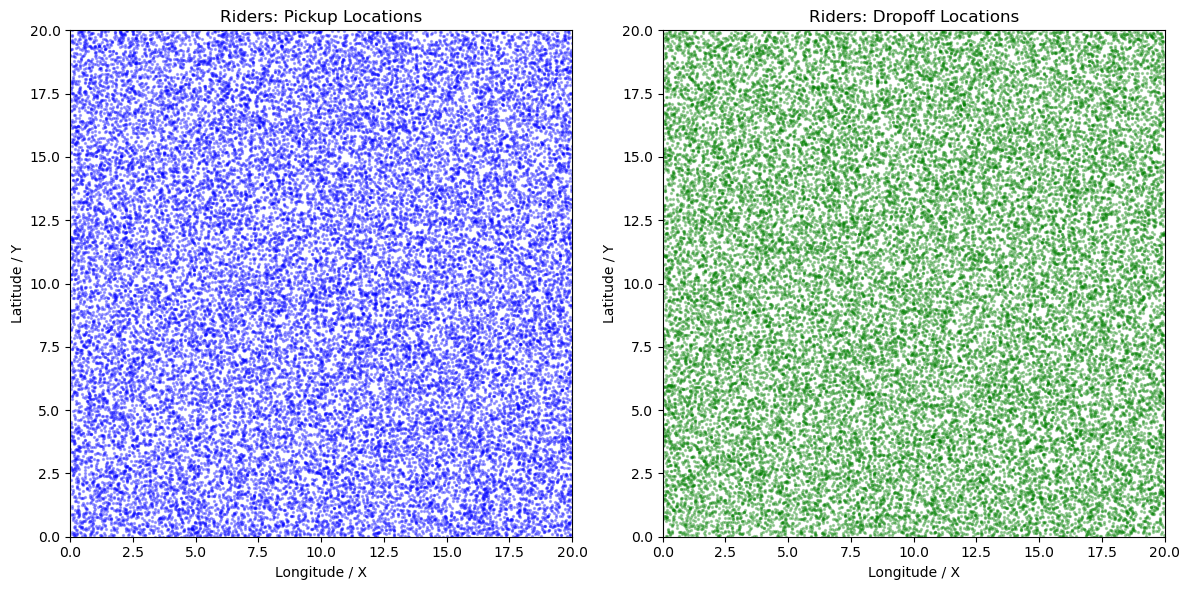

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

driver_df = pd.DataFrame(sim.driver_log)
rider_df = pd.DataFrame(sim.rider_log)

plt.figure(figsize=(12, 6))

# Pickup locations
plt.subplot(1, 2, 1)
plt.scatter(
    rider_df["origin_x"],
    rider_df["origin_y"],
    s=2,
    alpha=0.3,
    color="blue"
)
plt.xlim(0, AREA_SIZE)
plt.ylim(0, AREA_SIZE)
plt.xlabel("Longitude / X")
plt.ylabel("Latitude / Y")
plt.title("Riders: Pickup Locations")

# Dropoff locations
plt.subplot(1, 2, 2)
plt.scatter(
    rider_df["dest_x"],
    rider_df["dest_y"],
    s=2,
    alpha=0.3,
    color="green"
)
plt.xlim(0, AREA_SIZE)
plt.ylim(0, AREA_SIZE)
plt.xlabel("Longitude / X")
plt.ylabel("Latitude / Y")
plt.title("Riders: Dropoff Locations")

plt.tight_layout()
plt.show()

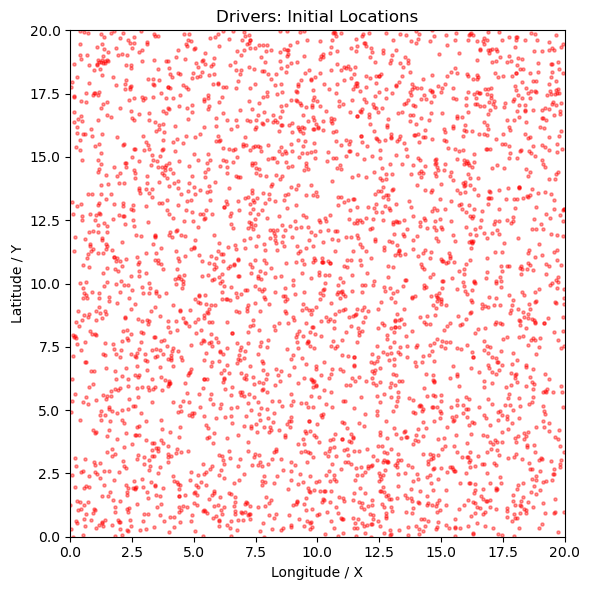

In [9]:
plt.figure(figsize=(6, 6))

plt.scatter(
    driver_df["initial_x"],
    driver_df["initial_y"],
    s=5,
    alpha=0.4,
    color="red"
)

plt.xlim(0, AREA_SIZE)
plt.ylim(0, AREA_SIZE)
plt.xlabel("Longitude / X")
plt.ylabel("Latitude / Y")
plt.title("Drivers: Initial Locations")

plt.tight_layout()
plt.show()